# Exploración de datos Sentinel-2

Este notebook contiene el análisis exploratorio inicial de las imágenes satelitales utilizadas para el proyecto de detección de deforestación e incendios forestales.

Se revisan:
- Estructura de los tiles
- Dimensiones de las imágenes
- Estadísticas básicas
- Visualización de imágenes PRE y POST
- Verificación de labels

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
tiles_path1 = "/content/drive/MyDrive/vision_sentinental_drive/tiles_par1"
labels_path1 = "/content/drive/MyDrive/vision_sentinental_drive/labels_par1"

tiles_path2 = "/content/drive/MyDrive/vision_sentinental_drive/tiles_par2"
labels_path2 = "/content/drive/MyDrive/vision_sentinental_drive/labels_par2"

tiles_path3 = "/content/drive/MyDrive/vision_sentinental_drive/tiles_par3"
labels_path3 = "/content/drive/MyDrive/vision_sentinental_drive/labels_par3"

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

In [4]:
print("Tiles parte 1:", len(os.listdir(tiles_path1)))
print("Labels parte 1:", len(os.listdir(labels_path1)))

print("Tiles parte 2:", len(os.listdir(tiles_path2)))
print("Labels parte 2:", len(os.listdir(labels_path2)))

print("Tiles parte 3:", len(os.listdir(tiles_path3)))
print("Labels parte 3:", len(os.listdir(labels_path3)))

Tiles parte 1: 32
Labels parte 1: 16
Tiles parte 2: 32
Labels parte 2: 16
Tiles parte 3: 32
Labels parte 3: 16


In [5]:
tiles = sorted([
    f for f in os.listdir(tiles_path1)
    if "pre" in f
])

tile_random = random.choice(tiles)

print("Tile seleccionado:", tile_random)

Tile seleccionado: tile_11_pre.npy


In [6]:
pre = np.load(
    os.path.join(
        tiles_path1,
        tile_random
    )
)

post_name = tile_random.replace("pre", "post")

post = np.load(
    os.path.join(
        tiles_path1,
        post_name
    )
)

print("PRE shape :", pre.shape)
print("POST shape:", post.shape)

PRE shape : (9, 512, 512)
POST shape: (9, 512, 512)


In [7]:
x = np.concatenate([pre, post], axis=0)

print("Shape final:", x.shape)

print("Min :", x.min())
print("Max :", x.max())
print("Mean:", x.mean())
print("Std :", x.std())

Shape final: (18, 512, 512)
Min : -0.31246967483928445
Max : 0.7224
Mean: 0.2261491818298248
Std : 0.17084819187618158


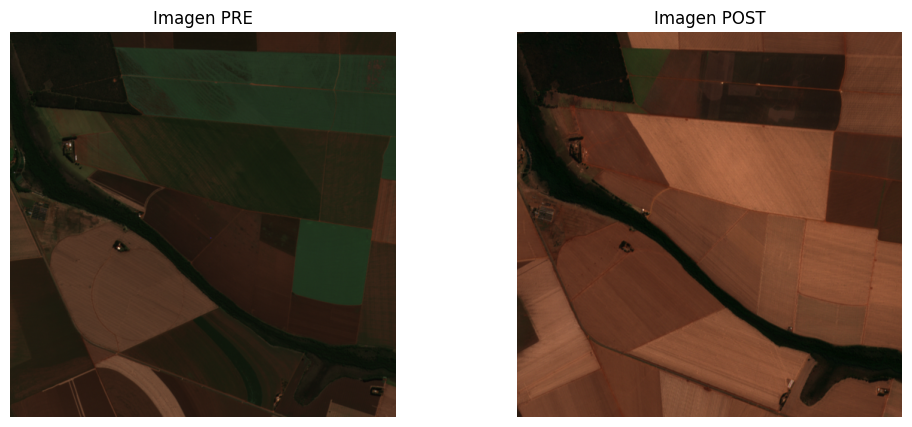

In [8]:
rgb_pre = np.transpose(pre[[2,1,0]], (1,2,0))
rgb_post = np.transpose(post[[2,1,0]], (1,2,0))

rgb_pre = (rgb_pre - rgb_pre.min()) / (rgb_pre.max() - rgb_pre.min())
rgb_post = (rgb_post - rgb_post.min()) / (rgb_post.max() - rgb_post.min())

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(rgb_pre)
plt.title("Imagen PRE")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb_post)
plt.title("Imagen POST")
plt.axis("off")

plt.show()

In [9]:
label_name = tile_random.replace("pre", "label")

label = np.load(
    os.path.join(
        labels_path1,
        label_name
    )
)

print("Label shape:", label.shape)

Label shape: (512, 512)


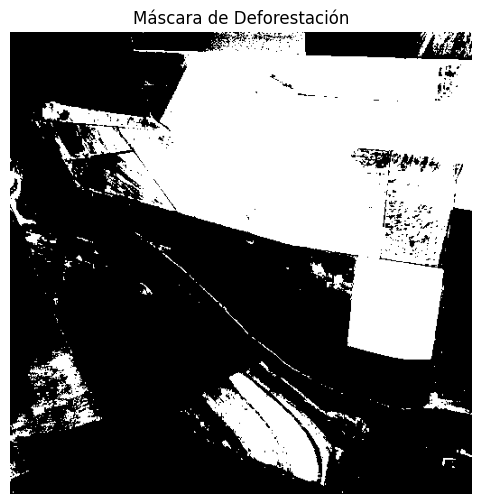

In [10]:
plt.figure(figsize=(6,6))

plt.imshow(label, cmap="gray")

plt.title("Máscara de Deforestación")

plt.axis("off")

plt.show()